In [1]:
!pip install -q resampy

import os
import time
import zipfile
import warnings

import gdown
import librosa
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")
%matplotlib inline

# Фиксируем генератор случайных чисел
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Версия TensorFlow:", tf.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 42.8 MB/s eta 0:00:00
Версия TensorFlow: 2.20.0


In [2]:
TESS_URL = "https://storage.yandexcloud.net/aiueducation/Content/base/l12/dataverse_files.zip"
SAVEE_URL = "https://storage.yandexcloud.net/aiueducation/Content/base/l12/archive.zip"

TESS_ZIP = "tess_data.zip"
SAVEE_ZIP = "savee_data.zip"
TESS_DIR = "./tess_dataset"
SAVEE_DIR = "./savee_dataset"


def download_file(url, output_name):
    gdown.download(url, output_name, quiet=True)


def unpack_archive(zip_name, target_dir):
    os.makedirs(target_dir, exist_ok=True)
    with zipfile.ZipFile(zip_name, "r") as archive:
        archive.extractall(target_dir)
    print(f"Архив {zip_name} распакован в {target_dir}")


download_file(TESS_URL, TESS_ZIP)
download_file(SAVEE_URL, SAVEE_ZIP)

unpack_archive(TESS_ZIP, TESS_DIR)
unpack_archive(SAVEE_ZIP, SAVEE_DIR)

Скачивание: tess_data.zip
Скачивание: savee_data.zip
Архив tess_data.zip распакован в ./tess_dataset
Архив savee_data.zip распакован в ./savee_dataset


In [3]:
EMOTIONS = {
    "angry": 0,
    "disgust": 1,
    "fear": 2,
    "happy": 3,
    "neutral": 4,
    "sad": 5,
    "surprise": 6,
}

NUM_CLASSES = len(EMOTIONS)
CLASS_NAMES = list(EMOTIONS.keys())
INDEX_TO_EMOTION = {index: emotion for emotion, index in EMOTIONS.items()}


def extract_feature_vector(audio_path):
    # Загружаем звук
    signal, sample_rate = librosa.load(audio_path, res_type="kaiser_fast")

    # MFCC описывают интонационные особенности речи
    mfcc = librosa.feature.mfcc(y=signal, sr=sample_rate, n_mfcc=40)
    mfcc_mean = np.mean(mfcc.T, axis=0)
    mfcc_std = np.std(mfcc.T, axis=0)

    # Mel описывает распределение энергии по частотным диапазонам
    mel = librosa.feature.melspectrogram(y=signal, sr=sample_rate)
    mel_mean = np.mean(mel.T, axis=0)
    mel_std = np.std(mel.T, axis=0)

    # Chroma добавляет информацию о распределении частот по полутонам
    chroma = librosa.feature.chroma_stft(y=signal, sr=sample_rate)
    chroma_mean = np.mean(chroma.T, axis=0)
    chroma_std = np.std(chroma.T, axis=0)

    return np.hstack([
        mfcc_mean,
        mfcc_std,
        mel_mean,
        mel_std,
        chroma_mean,
        chroma_std,
    ])

In [4]:
def get_tess_emotion(file_name):
    # Определяет эмоцию по имени файла из набора TESS
    name = file_name.lower()

    if "angry" in name:
        return "angry"
    if "disgust" in name:
        return "disgust"
    if "fear" in name:
        return "fear"
    if "happy" in name:
        return "happy"
    if "neutral" in name:
        return "neutral"
    if "sad" in name:
        return "sad"
    if "ps" in name or "surprise" in name:
        return "surprise"

    return None


def collect_tess_dataset(dataset_dir):
    # Проходит по всем wav файлам TESS и собирает признаки вместе с метками классов
    features = []
    labels = []

    for folder, _, files in os.walk(dataset_dir):
        for file_name in files:
            if not file_name.lower().endswith(".wav"):
                continue

            emotion = get_tess_emotion(file_name)
            if emotion is None:
                continue

            audio_path = os.path.join(folder, file_name)
            features.append(extract_feature_vector(audio_path))
            labels.append(EMOTIONS[emotion])

    return np.array(features, dtype=np.float32), np.array(labels, dtype=np.int64)


print("Разбор датасета TESS...")
start = time.time()

x_tess, y_tess = collect_tess_dataset(TESS_DIR)

print(f"Файлов обработано: {len(x_tess)}")
print(f"Время обработки: {round(time.time() - start)} сек.")

Разбор датасета TESS...
Файлов обработано: 2800
Время обработки: 147 сек.


In [5]:
# Делим TESS на обучение и тест
X_train, X_test, y_train, y_test = train_test_split(
    x_tess,
    y_tess,
    test_size=0.2,
    stratify=y_tess,
    random_state=SEED,
)

# Масштабирование признаков нужно для устойчивого обучения полносвязной сети
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keras модель обучается на представлении меток
y_train_ohe = to_categorical(y_train, num_classes=NUM_CLASSES)
y_test_ohe = to_categorical(y_test, num_classes=NUM_CLASSES)

print("Обучающая выборка:", X_train_scaled.shape)
print("Тестовая выборка:", X_test_scaled.shape)

Обучающая выборка: (2240, 360)
Тестовая выборка: (560, 360)


In [6]:
def build_emotion_classifier(input_size, class_count):
    # Архитектура сохранена по смыслу
    network = Sequential(name="emotion_dense_classifier")

    network.add(Input(shape=(input_size,)))

    network.add(Dense(512, activation="relu"))
    network.add(BatchNormalization())
    network.add(Dropout(0.3))

    network.add(Dense(256, activation="relu"))
    network.add(BatchNormalization())
    network.add(Dropout(0.3))

    network.add(Dense(128, activation="relu"))
    network.add(BatchNormalization())
    network.add(Dropout(0.2))

    network.add(Dense(class_count, activation="softmax"))

    network.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    return network


model = build_emotion_classifier(
    input_size=X_train_scaled.shape[1],
    class_count=NUM_CLASSES,
)

model.summary()

Model: "emotion_dense_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       184,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,543 (1.35 MB)

 Trainable params: 351,751 (1.34 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [7]:
history = model.fit(
    X_train_scaled,
    y_train_ohe,
    validation_data=(X_test_scaled, y_test_ohe),
    batch_size=32,
    epochs=30,
    verbose=1,
)

Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.8638 - loss: 0.4257 - val_accuracy: 0.9786 - val_loss: 0.1477
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9857 - loss: 0.0706 - val_accuracy: 0.9929 - val_loss: 0.0468
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9902 - loss: 0.0354 - val_accuracy: 0.9946 - val_loss: 0.0225
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9969 - loss: 0.0215 - val_accuracy: 0.9964 - val_loss: 0.0146
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9987 - loss: 0.0128 - val_accuracy: 0.9946 - val_loss: 0.0147
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9991 - loss: 0.0084 - val_accuracy: 0.9964 - val_loss: 0.0109
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9973 - loss: 0.0118 - val_accuracy: 0.9875 - val_loss: 0.0341
Epoch 8/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9969 - loss: 0.0121 - val_accuracy: 0.9911 - val_loss

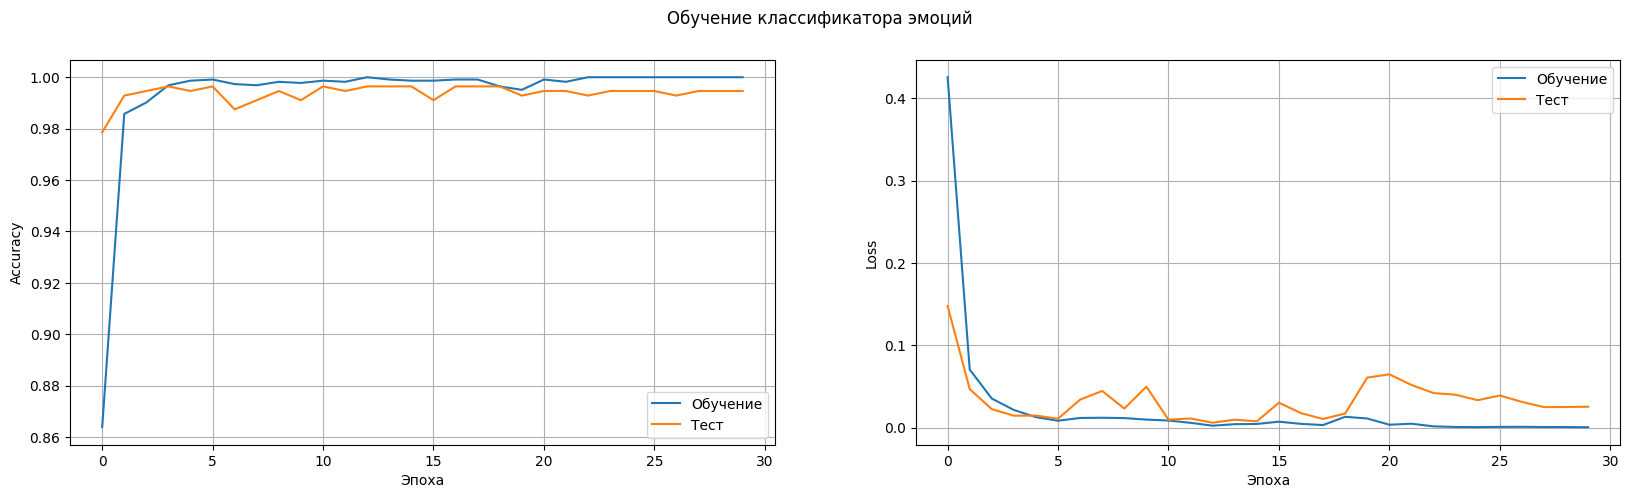

In [8]:
def plot_training_result(train_history):
    # Отдельно выводим точность и ошибку на обучении
    fig, axes = plt.subplots(1, 2, figsize=(20, 5))
    fig.suptitle("Обучение классификатора эмоций")

    axes[0].plot(train_history.history["accuracy"], label="Обучение")
    axes[0].plot(train_history.history["val_accuracy"], label="Тест")
    axes[0].set_xlabel("Эпоха")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(train_history.history["loss"], label="Обучение")
    axes[1].plot(train_history.history["val_loss"], label="Тест")
    axes[1].set_xlabel("Эпоха")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].grid(True)

    plt.show()


plot_training_result(history)

ИТОГОВАЯ ТОЧНОСТЬ НА ТЕСТОВОМ НАБОРЕ TESS: 99.46%
Выполнение условия технического задания (>= 98%): ВЫПОЛНЕНО!
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


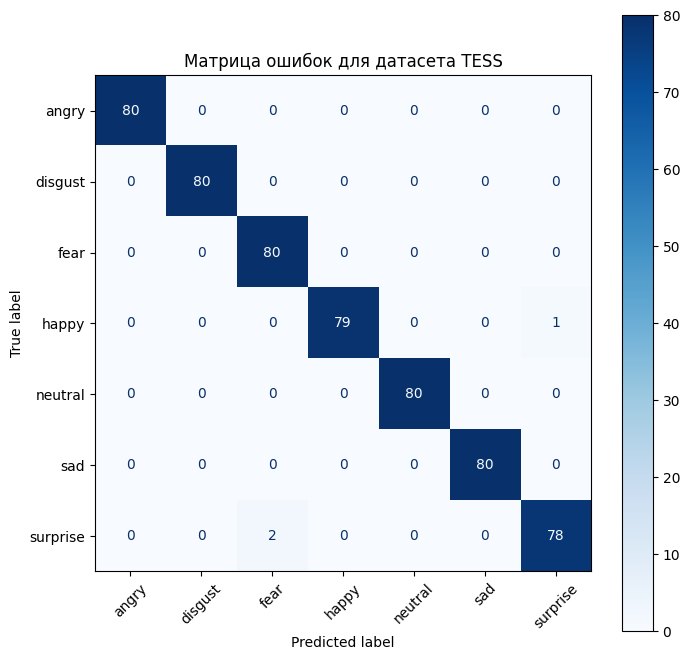

In [9]:
def show_confusion(y_true, y_pred, title, color_map):
    # Матрица ошибок показывает, какие эмоции модель путает между собой.
    matrix = confusion_matrix(y_true, y_pred)
    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=CLASS_NAMES,
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    display.plot(ax=ax, cmap=color_map, xticks_rotation=45)
    plt.title(title)
    plt.show()


test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test_ohe, verbose=0)

print("=" * 60)
print(f"ИТОГОВАЯ ТОЧНОСТЬ НА ТЕСТОВОМ НАБОРЕ TESS: {round(test_accuracy * 100, 2)}%")
print("Выполнение условия технического задания (>= 98%):", "ВЫПОЛНЕНО!" if test_accuracy >= 0.98 else "НЕ ВЫПОЛНЕНО.")
print("=" * 60)

tess_probabilities = model.predict(X_test_scaled)
tess_predicted = np.argmax(tess_probabilities, axis=1)

show_confusion(
    y_true=y_test,
    y_pred=tess_predicted,
    title="Матрица ошибок для датасета TESS",
    color_map="Blues",
)

In [10]:
SAVEE_CODES = {
    "a": "angry",
    "d": "disgust",
    "f": "fear",
    "h": "happy",
    "n": "neutral",
    "sa": "sad",
    "su": "surprise",
}


def get_savee_emotion(file_name):
    # В SAVEE эмоция закодирована во второй части имени файла
    base_name = os.path.splitext(file_name)[0]
    parts = base_name.split("_")

    if len(parts) < 2:
        return None

    raw_code = "".join(symbol for symbol in parts[1] if symbol.isalpha())
    return SAVEE_CODES.get(raw_code)


def collect_savee_dataset(dataset_dir):
    # Собирает признаки из SAVEE в том же формате что и для TESS
    features = []
    labels = []

    for folder, _, files in os.walk(dataset_dir):
        for file_name in files:
            if not file_name.lower().endswith(".wav"):
                continue

            emotion = get_savee_emotion(file_name)
            if emotion is None:
                continue

            audio_path = os.path.join(folder, file_name)
            features.append(extract_feature_vector(audio_path))
            labels.append(EMOTIONS[emotion])

    return np.array(features, dtype=np.float32), np.array(labels, dtype=np.int64)


print("Разбор датасета SAVEE...")
x_savee, y_savee = collect_savee_dataset(SAVEE_DIR)

print(f"Файлов обработано: {len(x_savee)}")

Разбор датасета SAVEE...
Файлов обработано: 480



ТОЧНОСТЬ КЛАССИФИКАТОРА НА ДАННЫХ SAVEE: 11.25%
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


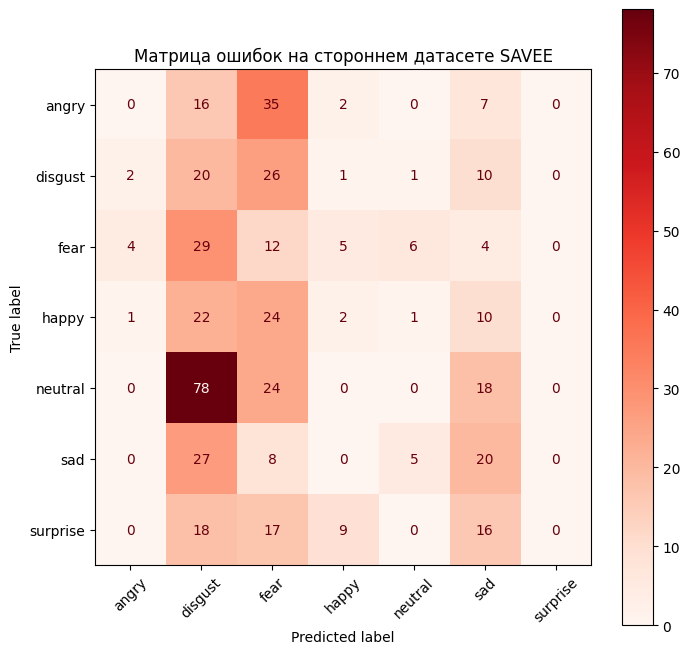

In [11]:
# Для SAVEE используем тот же scaler, который был обучен только на TESS
x_savee_scaled = scaler.transform(x_savee)
y_savee_ohe = to_categorical(y_savee, num_classes=NUM_CLASSES)

savee_loss, savee_accuracy = model.evaluate(x_savee_scaled, y_savee_ohe, verbose=0)

print("\n" + "=" * 60)
print(f"ТОЧНОСТЬ КЛАССИФИКАТОРА НА ДАННЫХ SAVEE: {round(savee_accuracy * 100, 2)}%")
print("=" * 60)

savee_probabilities = model.predict(x_savee_scaled)
savee_predicted = np.argmax(savee_probabilities, axis=1)

show_confusion(
    y_true=y_savee,
    y_pred=savee_predicted,
    title="Матрица ошибок на стороннем датасете SAVEE",
    color_map="Reds",
)